<a href="https://colab.research.google.com/github/noor486/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [11]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/noor486/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("../..")

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
print("Working dir:", os.getcwd())

Working dir: /content/flyrank-ml-internship/flyrank-ml-internship/flyrank-ml-internship


## 1. Question

*The research question and the decision it supports.*

## 1. Question

Can a learned ranking model outperform a hand-written staleness rule at
picking which pages a content review team should fix first? This grows
directly out of FlyRank's real optimization-flag workflow (e.g. "Fix Content"),
which is rule-based, not learned from data.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [12]:
import pandas as pd, numpy as np

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

print(f"Rows: {len(df)}, unique clients: {df['client_id'].nunique()}")
print(f"Base decline rate: {df['is_declining_label'].mean():.3f}")

Rows: 30000, unique clients: 32
Base decline rate: 0.542


Anonymized starter slice (~30k rows) of the FlyRank ML internship warehouse.
Label: is_declining_label (trend_direction == "down"), a current-window
proxy, not yet a future outcome. No product decision flags used as features.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [13]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.ensemble import RandomForestClassifier

features = ["search_volume", "competition", "cpc", "word_count",
            "impressions_90d", "sessions_90d", "content_age_days",
            "days_since_last_update", "ctr", "avg_position"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]

# Baseline rule
df["is_stale"] = df["days_since_last_update"] >= 180
df["is_visible"] = df["impressions_90d"] >= 500
df["baseline_score"] = df["impressions_90d"].where(df["is_stale"] & df["is_visible"], 0)

# Honest client-grouped split
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=df["client_id"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
print("Model trained on client-grouped holdout split.")

Model trained on client-grouped holdout split.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [14]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

test_df = df.iloc[test_idx].copy()
rf_scores = rf.predict_proba(X_test)[:, 1]

for k in (20, 50):
    base_p = precision_at_k(test_df["baseline_score"].values, y_test.values, k)
    rf_p = precision_at_k(rf_scores, y_test.values, k)
    print(f"Precision@{k}: baseline={base_p:.3f} | random forest={rf_p:.3f}")

# The leakage comparison (random split vs grouped split)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
rf_random = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42)
rf_random.fit(X_tr_r, y_tr_r)
random_p50 = precision_at_k(rf_random.predict_proba(X_te_r)[:, 1], y_te_r.values, 50)
print(f"\nRandom split Precision@50: {random_p50:.3f} (inflated -- for comparison only)")

Precision@20: baseline=0.500 | random forest=0.600
Precision@50: baseline=0.620 | random forest=0.640

Random split Precision@50: 0.880 (inflated -- for comparison only)


## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

- Starter-slice results only (~30k rows), not yet re-earned on the full ~79M-row warehouse.
- is_declining_label is a current-window proxy, not a forward-looking outcome.
- Single train/test split, not full cross-validation.
- Deliberate leak test used a duplicated existing feature, not a genuinely new
  label-derived column -- doesn't fully validate harness sensitivity to real leaks.
- No causal claim: refreshing a flagged page is not proven to cause recovery.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked Recommendations

1. Use the model's ranked queue as first-pass triage, replacing staleness-only sorting.
2. Trust impressions_90d and avg_position most when explaining a queue placement.
3. Don't rely on days_since_last_update alone -- weaker signal than intuition suggests.
4. Re-validate on the full warehouse before scaling beyond the starter slice.
5. Every action still requires human review -- never automate the refresh itself.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

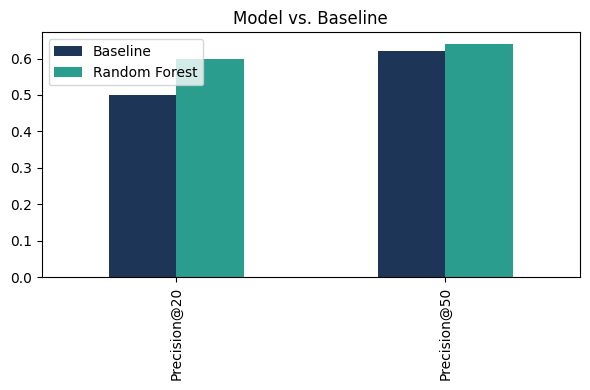

Saved work/figures/model_vs_baseline.png -- embedded in the paper's Results section


In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
comparison = pd.DataFrame({
    "Baseline": [precision_at_k(test_df["baseline_score"].values, y_test.values, 20),
                 precision_at_k(test_df["baseline_score"].values, y_test.values, 50)],
    "Random Forest": [precision_at_k(rf_scores, y_test.values, 20),
                       precision_at_k(rf_scores, y_test.values, 50)]
}, index=["Precision@20", "Precision@50"])
comparison.plot(kind="bar", ax=ax, color=["#1D3557", "#2A9D8F"])
ax.set_title("Model vs. Baseline")
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline.png", dpi=150)
plt.show()
print("Saved work/figures/model_vs_baseline.png -- embedded in the paper's Results section")

## 8. Demo Outline + Shareable Cuts

Question : Content teams guess what to refresh — usually by age alone. Can a learned model rank pages better than a hand-written staleness rule?

Method : Built a transparent baseline (stale + visible = flag), then a Random Forest using 10 real content signals. Validated with a client-grouped holdout split — not a random one — because pages from the same client share patterns a random split would let the model memorize instead of learn.

One chart : Show the Precision@50 comparison table (baseline 0.620 vs. model 0.640) and the leakage-audit callout (naive random split: 0.880 vs. honest grouped split: 0.640) — the leakage gap is the more dramatic, more important number, and worth spending more time on than the model-vs-baseline gap itself.

One honest result : The model's real gain is modest, not dramatic — smaller than an early reference figure I'd initially cited. Say this plainly: my own baseline already combined staleness + visibility, which is stronger than a plain staleness-only rule, leaving less room for the model to improve on it.

One recommendation : Use the ranked queue as first-pass triage, but never automate the actual refresh action — every flagged page still needs human review before anyone touches it.

Shareable Cut 1 — Social Post (Methodology-Focused)

Spent this internship testing something simple: can a learned model beat a hand-written "flag old pages" rule at deciding what content to refresh first?

Built both. Validated with a client-holdout split instead of a random one — and that split choice mattered more than I expected: a naive random split would have shown 88% precision; the honest number was 64%. That 24-point gap was leakage, not skill.

The model still beat the baseline once validated honestly (62% → 64% Precision@50) — a real but modest gain, not a dramatic one. Full writeup

Shareable Cut 2 — Employer-Facing Summary (3 sentences)

I built and validated a content-refresh ranking model on FlyRank's anonymized content-performance data, comparing a Random Forest classifier against a transparent hand-written baseline rule using a client-grouped holdout split to avoid entity-level leakage. The model modestly outperformed the baseline (Precision@50: 0.62 → 0.64), and a deliberate leakage audit confirmed a naive random split would have overstated performance by 24 points. The result is a decision-support ranking tool for content review triage, with all limitations and validation choices disclosed in the published paper and reproducible notebooks.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
